# Kazakh khans by year

A century × year tile chart of Kazakh khans: each year is a colored rectangle, empty years are gaps (power vacuum), and overlapping reigns become stacked stripes.

The idea follows the [Barely Maps Roman emperors chart](https://www.barelymaps.com/558tiziwfm675vxkeajhvu4oah7pdn) and the matrix look of [missingno](https://github.com/ResidentMario/missingno).

| Path | Role |
|---|---|
| `data/kazakh_khans.tsv` | Reign list (repo root) |
| `notebooks/rulers_chart/data.py` | Load TSV, build the century × year grid |
| `notebooks/rulers_chart/plot.py` | Draw tiles, legend, captions |
| `notebooks/artifacts/` | Saved SVG and PNG charts |

Layout: **x** is the year inside the century (`1456` → column `56`), **y** is the century row (`1456` → row `14`, labeled 1400s).

In [1]:
%matplotlib inline

import sys
from pathlib import Path

import pandas as pd

here = Path.cwd().resolve()
nb_dir = next(
    candidate
    for candidate in (here, *here.parents)
    if (candidate / "rulers_chart" / "__init__.py").exists()
)
if str(nb_dir) not in sys.path:
    sys.path.insert(0, str(nb_dir))

root = nb_dir.parent  # repo root (shared data/)
from rulers_chart import build_year_grid, load_rulers, plot_rulers
from rulers_chart.data import EMPTY

## 1. Reign list

The table lives in `data/kazakh_khans.tsv`. Source: [List of Kazakh khans](https://en.wikipedia.org/wiki/List_of_Kazakh_khans) and [Казахский хан](https://ru.wikipedia.org/wiki/%D0%9A%D0%B0%D0%B7%D0%B0%D1%85%D1%81%D0%BA%D0%B8%D0%B9_%D1%85%D0%B0%D0%BD).

Unicode prefixes on names are leftover category tags (not parsed into a column yet):

| Prefix | Meaning here |
|---|---|
| `ᴭ` | Contested / civil-war period |
| `ᶬ` | Post-Tauke main line |
| `ᴶ` | Junior Juz (Kishi) |
| `ᴹ` | Middle Juz (Orta) |
| `ᴮ` | Bokei Horde |

Periods mix en-dashes and an ASCII hyphen (`Batyr Khan`); the parser accepts both. End years are **inclusive**, so adjacent Wikipedia periods can share a year.

In [2]:
table = load_rulers(
    root / "data" / "kazakh_khans.tsv",
    name_col="Name",
    reign_col="Ruling period",
)
table.head()

,Name,Ruling period,Name in Kazakh,start,end,start_century,end_century,chart_label,ruler_id
0,Kerei,1456–1473,"Керей, كيري",1456,1473,15,15,Kerei 1456-1473,1
1,Janibek,1473–1480,"Жәнібек, جانيبك",1473,1480,15,15,Janibek 1473-1480,2
2,Burunduk,1480–1511,"Бұрындық (Мұрындық), بورونديق",1480,1511,15,16,Burunduk 1480-1511,3
3,Qasim,1511–1518,"Қасым, قاسم",1511,1518,16,16,Qasim 1511-1518,4
4,ᴭMuhammed,1518–1523,"Мұхаммед, محمد",1518,1523,16,16,ᴭMuhammed 1518-1523,5


## 2. Parse and rasterize

`load_rulers(path, name_col=..., reign_col=...)` / `parse_rulers` split those columns into `start` / `end`, add centuries, legend labels, and a 1-based `ruler_id` (that id is the color index).

`build_year_grid` fills every calendar year with the khans who reigned then, then reshapes to 19 centuries × 100 years. Year `1456` lives at `year_grid[14][56]`.

In [3]:
year_grid = build_year_grid(table)
table[["ruler_id", "Name", "start", "end", "start_century", "chart_label"]]

,ruler_id,Name,start,end,start_century,chart_label
0,1,Kerei,1456,1473,15,Kerei 1456-1473
1,2,Janibek,1473,1480,15,Janibek 1473-1480
2,3,Burunduk,1480,1511,15,Burunduk 1480-1511
3,4,Qasim,1511,1518,16,Qasim 1511-1518
4,5,ᴭMuhammed,1518,1523,16,ᴭMuhammed 1518-1523
5,6,ᴭTahir,1523,1533,16,ᴭTahir 1523-1533
6,7,ᴭBuidash,1533,1538,16,ᴭBuidash 1533-1538
7,8,ᴭAhmed,1533,1535,16,ᴭAhmed 1533-1535
8,9,ᴭToghym,1535,1537,16,ᴭToghym 1535-1537
9,10,ᴭHaqnazar,1538,1580,16,ᴭHaqnazar 1538-1580


A few years from the grid, by name: overlap in the 1530s, a shared handover year, and a hole before Kenesary.

In [4]:
id_to_name = table.set_index("ruler_id")["Name"]

def who(year: int) -> list[str]:
    ids = year_grid[year // 100][year % 100]
    if ids == [EMPTY]:
        return []
    return [id_to_name[ruler_id] for ruler_id in ids]

for year in (1456, 1473, 1534, 1782, 1830, 1841):
    names = who(year)
    print(f"{year}: {names if names else '(gap)'}")

1456: ['Kerei']
1473: ['Kerei', 'Janibek']
1534: ['ᴭBuidash', 'ᴭAhmed']
1782: ['ᴶNur Ali', 'ᴹWäli']
1830: ['ᴮJäñgir']
1841: ['ᴮJäñgir', 'Kenesary Khan']


## 3. Charts

`plot_rulers` draws the tiles. Light theme sorts overlap stripes and writes SVG `gid`s; dark theme keeps table order.

findfont: Failed to find font weight heavy, now using 700.
findfont: Failed to find font weight light, now using 400.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
fi

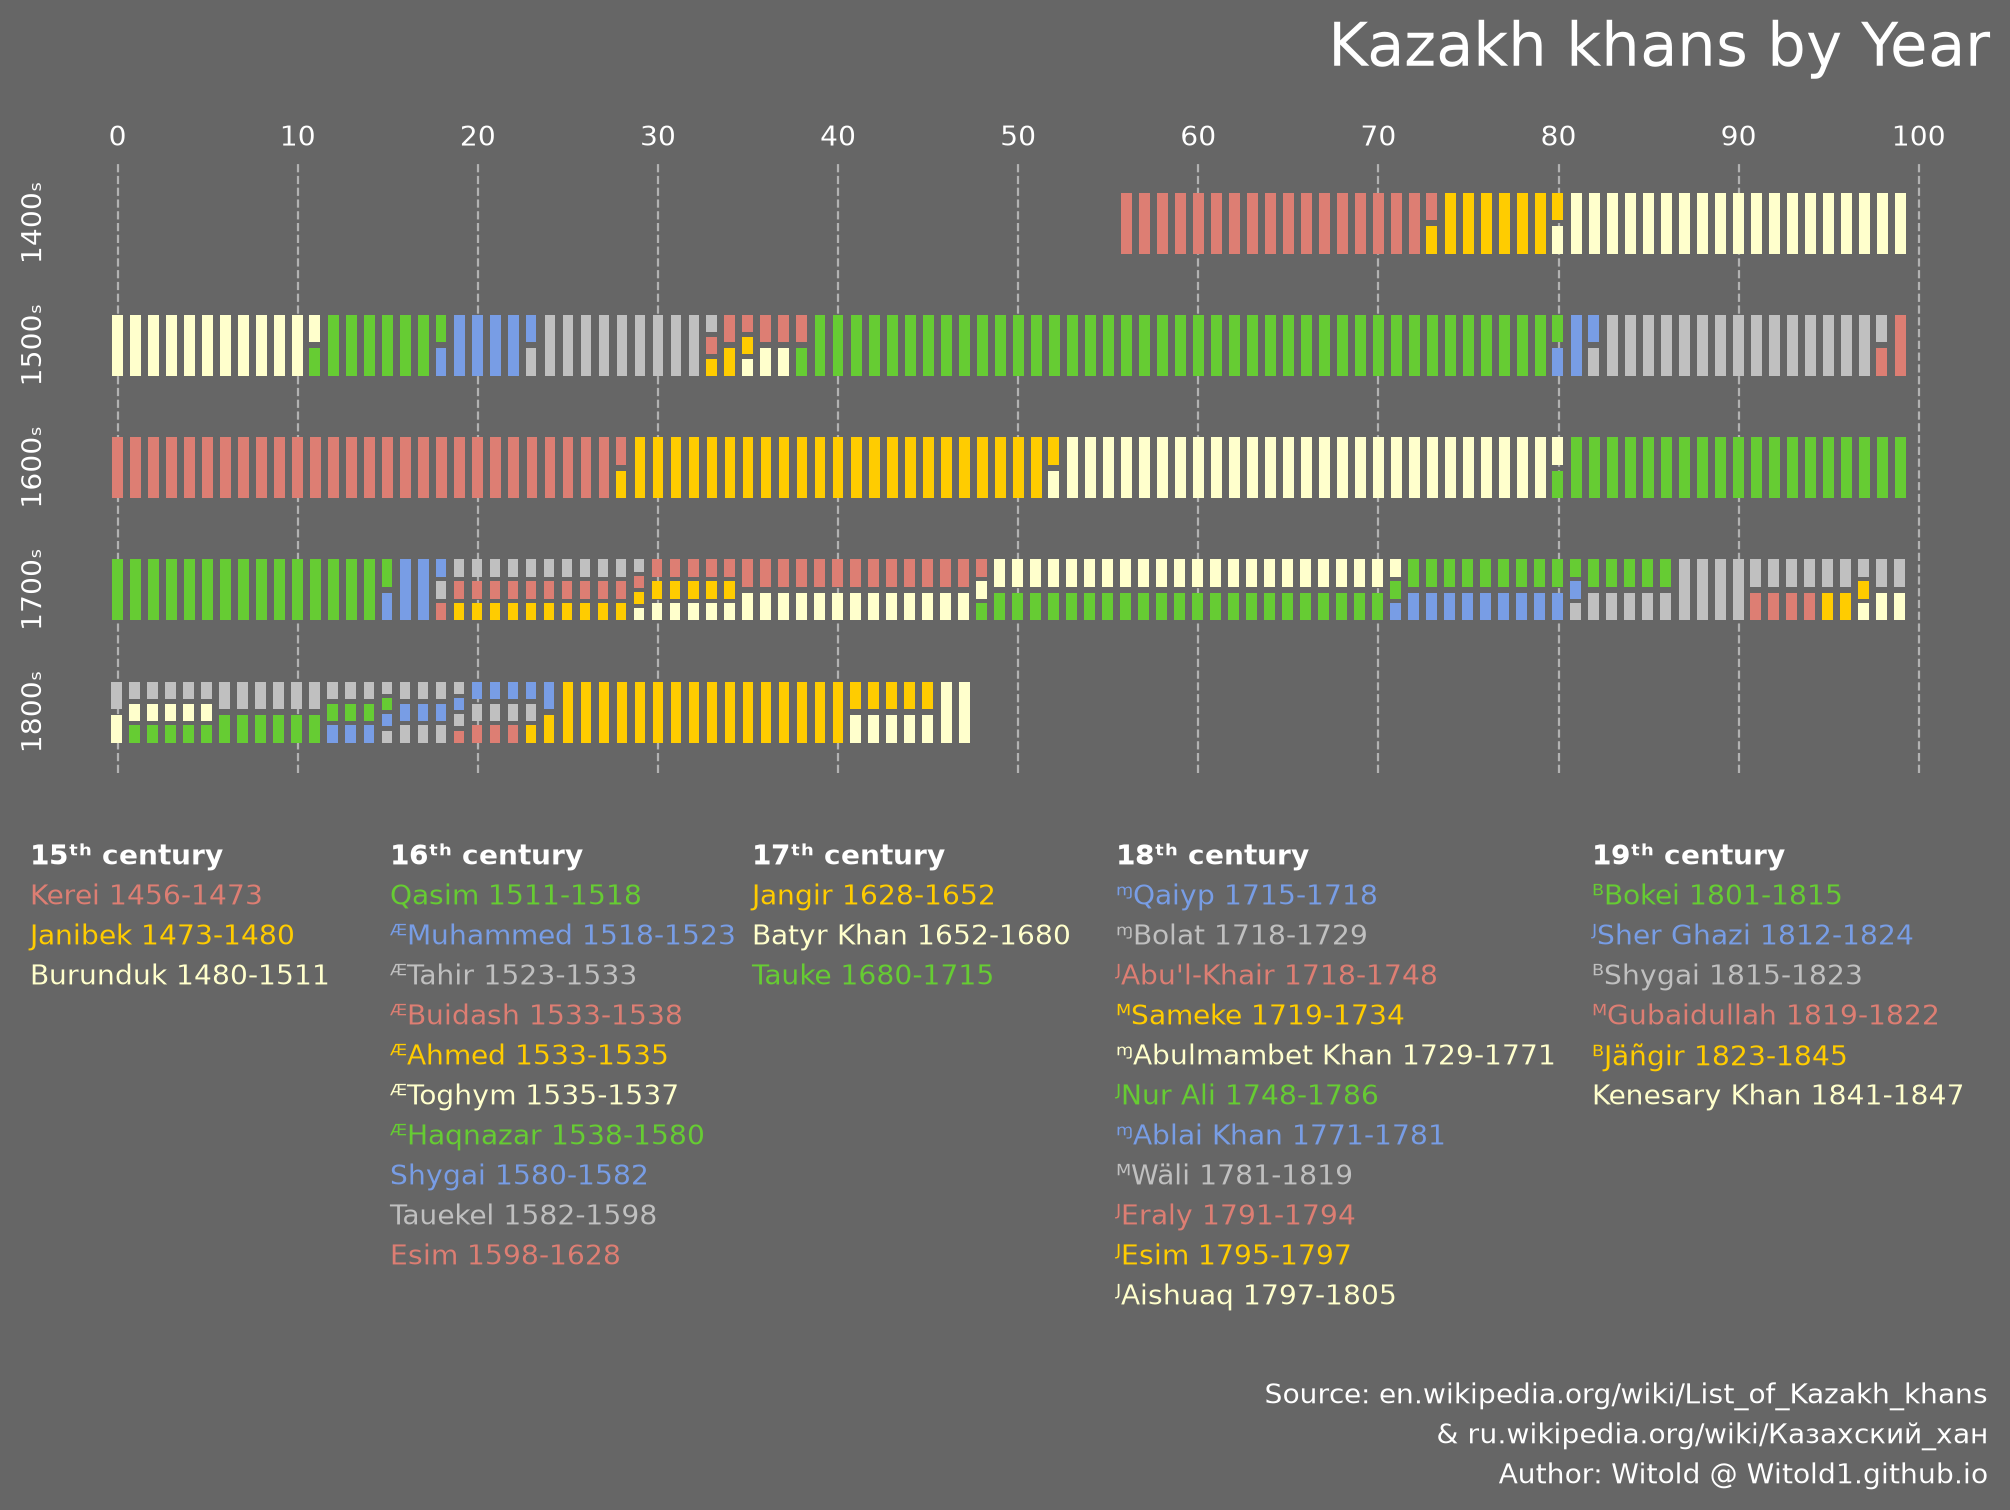

In [5]:
# Writes notebooks/artifacts/kazakh_khans_dark.svg and .png
plot_rulers(table, year_grid, theme="dark", save_stem="kazakh_khans_dark");

findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.
findfont: Font family 'mono' not found.


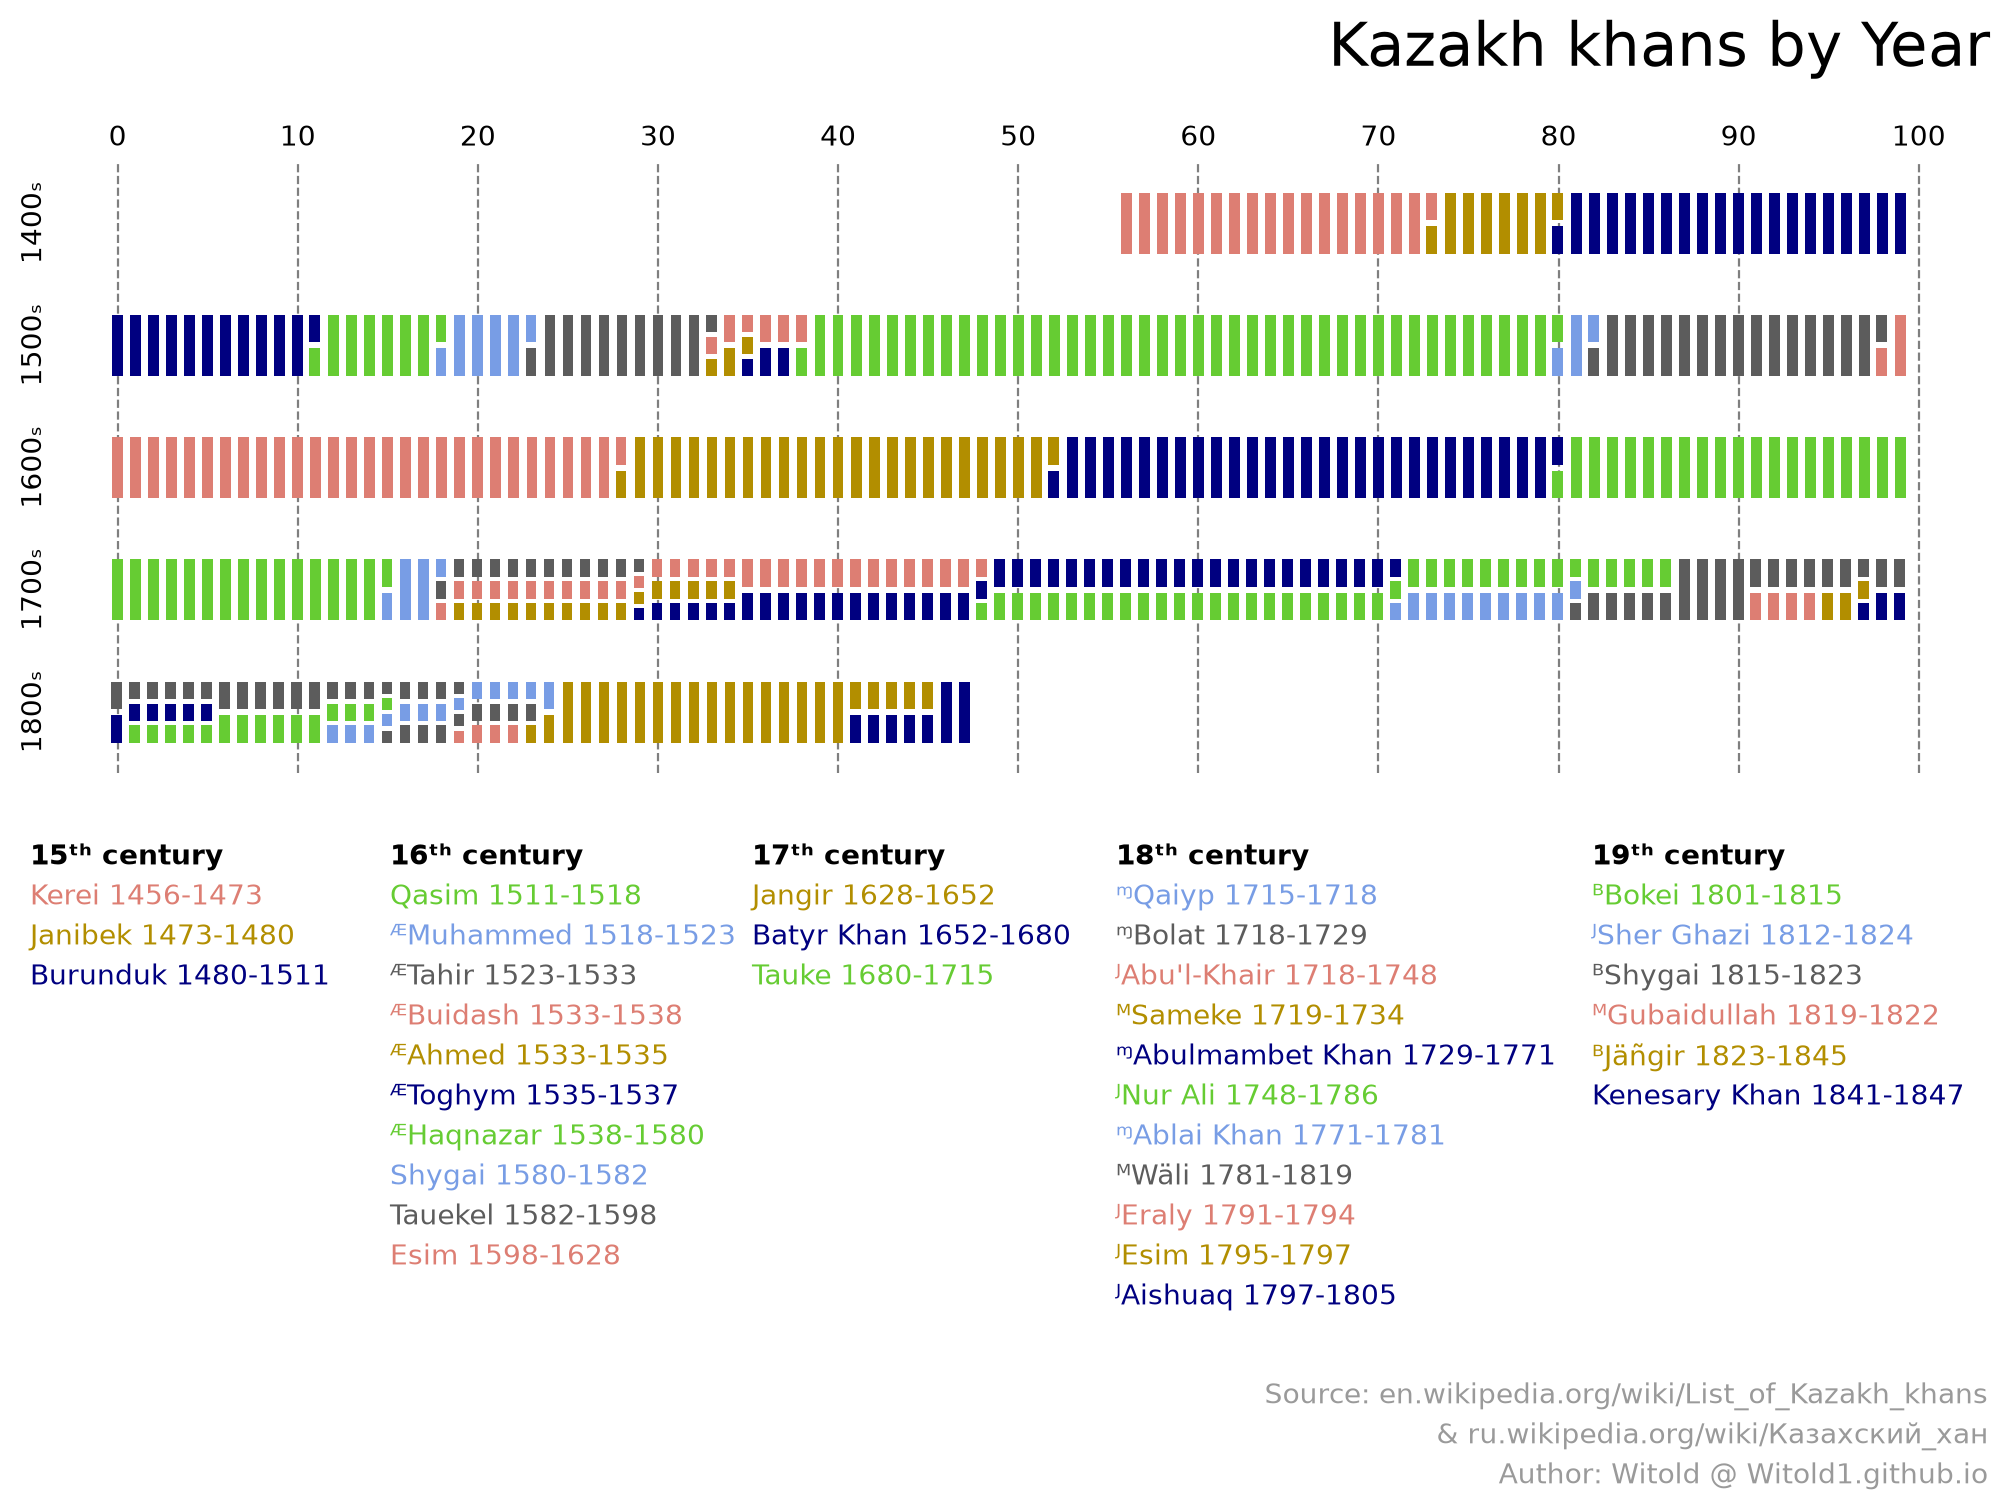

In [6]:
# Writes notebooks/artifacts/kazakh_khans_light.svg and .png
plot_rulers(table, year_grid, theme="light", save_stem="kazakh_khans_light");

Author: [Witold](https://witold1.github.io).